In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import joblib
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Đọc dữ liệu từ 2 Bảng Vàng (Đã sạch, Scale và SMOTE)
from sqlalchemy import create_engine
import urllib
server = 'localhost,1433'
database = 'fintech'
username = 'sa'
password = 'huong6978'
connection_string = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password};'
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
train_gold = pd.read_sql_query("SELECT * FROM gold_credit_risk_train", engine)
test_gold = pd.read_sql_query("SELECT * FROM gold_credit_risk_test", engine)

# Tách features (X) và target (y)
X_train = train_gold.drop('loan_status', axis=1)
y_train = train_gold['loan_status']
X_test = test_gold.drop('loan_status', axis=1)
y_test = test_gold['loan_status']

In [9]:
# 7 Cột số ban đầu
num_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file']

# Các cột One-Hot (Là tất cả các cột còn lại trừ đi cột số)
ohe_features = [col for col in X_train.columns if col not in num_features]

# Tách thành 2 cụm riêng biệt cho Train
X_train_num = X_train[num_features]
X_train_ohe = X_train[ohe_features]

# Tách thành 2 cụm riêng biệt cho Test
X_test_num = X_test[num_features]
X_test_ohe = X_test[ohe_features]

== KẾT QUẢ TÍNH TOÁN TỐI ƯU TOÁN HỌC ==
Theo Tiêu chuẩn Kaiser, chỉ có 3 thành phần đầu tiên có Eigenvalue > 1.0
Việc giữ lại 3 cột này sẽ bảo toàn được 67.41% thông tin tinh túy nhất.
Các cột từ PC4 trở đi chỉ mang tính chất nhiễu (Noise), nên bị loại bỏ.

PC1: Eigenvalue = 1.9259 | Tích lũy = 26.30%
PC2: Eigenvalue = 1.6195 | Tích lũy = 48.42%
PC3: Eigenvalue = 1.3906 | Tích lũy = 67.41%
PC4: Eigenvalue = 0.8916 | Tích lũy = 79.59%
PC5: Eigenvalue = 0.7747 | Tích lũy = 90.17%
PC6: Eigenvalue = 0.5338 | Tích lũy = 97.46%
PC7: Eigenvalue = 0.1863 | Tích lũy = 100.00%


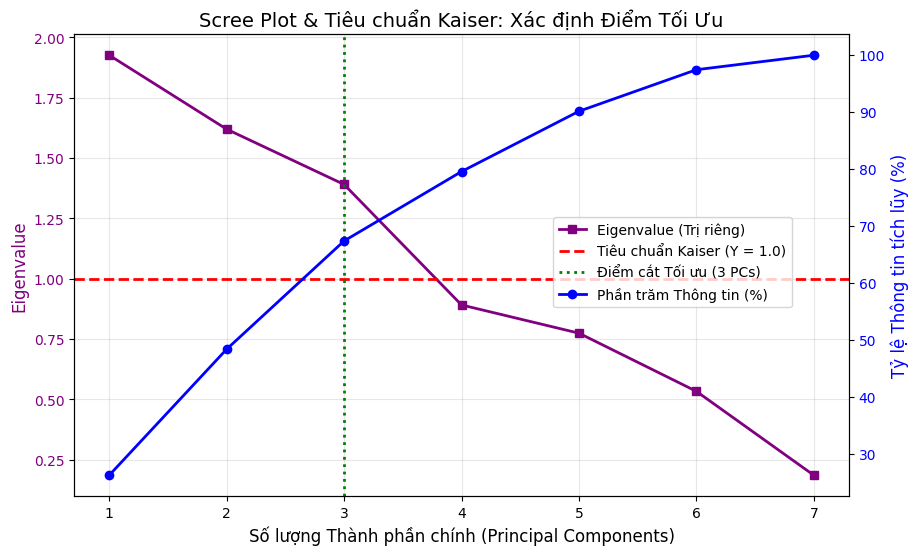

In [10]:
# Chạy PCA thử nghiệm trên toàn bộ 7 cột số
pca_test = PCA()
pca_test.fit(X_train_num)

eigenvalues = pca_test.explained_variance_
cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

# Xác định số lượng PC tối ưu theo Tiêu chuẩn Kaiser (Eigenvalue > 1.0)
optimal_kaiser_components = len(eigenvalues[eigenvalues > 1.0])
optimal_variance_retained = cumulative_variance[optimal_kaiser_components - 1] * 100

print(f"== KẾT QUẢ TÍNH TOÁN TỐI ƯU TOÁN HỌC ==")
print(f"Theo Tiêu chuẩn Kaiser, chỉ có {optimal_kaiser_components} thành phần đầu tiên có Eigenvalue > 1.0")
print(f"Việc giữ lại {optimal_kaiser_components} cột này sẽ bảo toàn được {optimal_variance_retained:.2f}% thông tin tinh túy nhất.")
print(f"Các cột từ PC{optimal_kaiser_components + 1} trở đi chỉ mang tính chất nhiễu (Noise), nên bị loại bỏ.\n")

for i in range(len(eigenvalues)):
    print(f"PC{i+1}: Eigenvalue = {eigenvalues[i]:.4f} | Tích lũy = {cumulative_variance[i]*100:.2f}%")

# Vẽ biểu đồ Scree Plot kết hợp Kaiser
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='s', linestyle='-', color='purple', linewidth=2, label='Eigenvalue (Trị riêng)')
ax1.axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Tiêu chuẩn Kaiser (Y = 1.0)')
ax1.axvline(x=optimal_kaiser_components, color='green', linestyle=':', linewidth=2, label=f'Điểm cắt Tối ưu ({optimal_kaiser_components} PCs)')

ax1.set_title('Scree Plot & Tiêu chuẩn Kaiser: Xác định Điểm Tối Ưu', fontsize=14)
ax1.set_xlabel('Số lượng Thành phần chính (Principal Components)', fontsize=12)
ax1.set_ylabel('Eigenvalue', fontsize=12, color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.set_xticks(range(1, len(eigenvalues) + 1))
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='-', color='blue', linewidth=2, label='Phần trăm Thông tin (%)')
ax2.set_ylabel('Tỷ lệ Thông tin tích lũy (%)', fontsize=12, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

fig.legend(loc='center right', bbox_to_anchor=(0.85, 0.5))
plt.show()

In [11]:
# Khởi tạo PCA với số chiều tối ưu
pca_final = PCA(n_components=optimal_kaiser_components, random_state=42)

# NGUYÊN TẮC VÀNG: fit_transform trên Train, nhưng CHỈ transform trên Test
X_train_pca_num = pca_final.fit_transform(X_train_num)
X_test_pca_num = pca_final.transform(X_test_num)

print(f"Đã thực thi nén dữ liệu từ 7 cột xuống còn {optimal_kaiser_components} cột PCA tối ưu.")

# Đặt lại tên cột cho đẹp (PC1, PC2...)
pca_col_names = [f'PC{i+1}' for i in range(optimal_kaiser_components)]
df_train_pca_num = pd.DataFrame(X_train_pca_num, columns=pca_col_names)
df_test_pca_num = pd.DataFrame(X_test_pca_num, columns=pca_col_names)

Đã thực thi nén dữ liệu từ 7 cột xuống còn 3 cột PCA tối ưu.


In [12]:
# Ghép nối (Concatenate) dữ liệu nén và dữ liệu One-Hot
X_train_final_pca = pd.concat([df_train_pca_num, X_train_ohe.reset_index(drop=True)], axis=1)
X_test_final_pca = pd.concat([df_test_pca_num, X_test_ohe.reset_index(drop=True)], axis=1)

# Thêm cột target y vào cuối
train_pca_table = pd.concat([X_train_final_pca, y_train.reset_index(drop=True)], axis=1)
test_pca_table = pd.concat([X_test_final_pca, y_test.reset_index(drop=True)], axis=1)

# Lưu trữ vào Database thành 2 bảng hoàn toàn mới
train_pca_table.to_sql("pca_credit_risk_train", engine, if_exists="replace", index=False)
test_pca_table.to_sql("pca_credit_risk_test", engine, if_exists="replace", index=False)
engine.dispose()

# Lưu lại mô hình PCA để Production sử dụng sau này
joblib.dump(pca_final, 'pca_model.pkl')

print("Hoàn tất! Đã lưu 2 bảng mới ('pca_credit_risk_train' và 'pca_credit_risk_test') vào Database.")
print("Dữ liệu này giờ đây cực kỳ đặc (dense), không còn đa cộng tuyến, SẴN SÀNG 100% cho thuật toán K-MEANS!")

Hoàn tất! Đã lưu 2 bảng mới ('pca_credit_risk_train' và 'pca_credit_risk_test') vào Database.
Dữ liệu này giờ đây cực kỳ đặc (dense), không còn đa cộng tuyến, SẴN SÀNG 100% cho thuật toán K-MEANS!
